# 78 mg/dL en 4 horas. Sin una sola aguja.

Un polímero zwitteriónico (OP) atraviesa la piel intacta y lleva insulina al torrente sanguíneo. En ratones diabéticos, la glucemia cayó de **487 mg/dL al rango normal** tras una sola aplicación tópica. Y los autores lo replicaron en minicerdos.

| | |
|---|---|
| **Paper** | Wei *et al.* (2025), *Nature* |
| **DOI** | [10.1038/s41586-025-09729-x](https://doi.org/10.1038/s41586-025-09729-x) |
| **Datos** | Source Data Fig. 3 (Springer ESM, MOESM14) |
| **Video** | [Ver en YouTube Shorts](https://youtube.com/shorts/uGReH2mVx8g) |

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-01-17-polimero-insulina-sin-agujas/notebook.ipynb)


## El problema

La insulina pesa 5800 daltons. La piel solo deja pasar moléculas pequeñas (<500 daltons) y con la hidrofobicidad correcta — por eso las inyecciones existen. Hace décadas que se intenta meter proteínas por la piel sin agujas; los geles, los parches, los polímeros conocidos rebotan.

El equipo de Wei diseñó un polímero llamado **OP** que cambia su carga eléctrica con el pH: en el medicamento es zwitteriónico (cero carga neta), en la piel se vuelve catiónico (carga positiva) y forma puentes con la matriz lipídica del estrato córneo. Eso le abre paso a la insulina.

Veamos los datos crudos de los tres experimentos clave de la Fig 3 — ratones a dosis alta, dosis-respuesta, y minicerdos diabéticos.


In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
RANGO_NORMAL = (50, 200)           # mg/dL — área sombreada en gráficas
COLOR_OP = "#2563EB"               # azul CaM — el polímero del paper
COLOR_INSULIN_SC = "#DC2626"       # rojo — comparador (insulina inyectada)
COLOR_PEG = "#7C3AED"              # violeta — control polímero no penetrante
COLOR_TRANSD = "#059669"           # esmeralda — insulina libre transdérmica
COLOR_PBS = "#999999"              # gris — control vehículo
COLOR_RANGO = "#D97706"            # amber — banda rango normal
FUENTE = "Fuente: Wei et al. (2025), Nature | DOI: 10.1038/s41586-025-09729-x"

# ══════════════════════════════════════════════════════════════
# Setup
# ══════════════════════════════════════════════════════════════
import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Estilo CaM (local → fallback GitHub raw)
BASE = "https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main"
style_file = "../../cam.mplstyle"
if not os.path.exists(style_file):
    style_file = "/tmp/cam.mplstyle"
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f"{BASE}/cam.mplstyle", style_file)
plt.style.use(style_file)

os.makedirs("figuras", exist_ok=True)

# ══════════════════════════════════════════════════════════════
# Carga de los 3 datasets verificados
# ══════════════════════════════════════════════════════════════
df_mice = pd.read_csv("datos/bgl_mice_116ukg.csv")
df_dose = pd.read_csv("datos/bgl_mice_dose_response.csv")
df_pigs = pd.read_csv("datos/bgl_minipigs_29ukg.csv")

print(f"Ratones T1D (116 U/kg): {len(df_mice)} mediciones · "
      f"{df_mice['group'].nunique()} grupos · "
      f"{df_mice.groupby('group')['mouse_id'].nunique().iloc[0]} ratones/grupo")
print(f"Ratones dosis-respuesta:  {len(df_dose)} mediciones · "
      f"dosis: {sorted(df_dose['dose'].unique())}")
print(f"Minicerdos diabéticos:    {len(df_pigs)} mediciones · "
      f"{df_pigs['group'].nunique()} grupos · "
      f"{df_pigs.groupby('group')['pig_id'].nunique().iloc[0]} cerdos/grupo")


Ratones T1D (116 U/kg): 320 mediciones · 5 grupos · 8 ratones/grupo
Ratones dosis-respuesta:  128 mediciones · dosis: ['29 U/kg', '58 U/kg']
Minicerdos diabéticos:    105 mediciones · 5 grupos · 3 cerdos/grupo


## Aquí está.


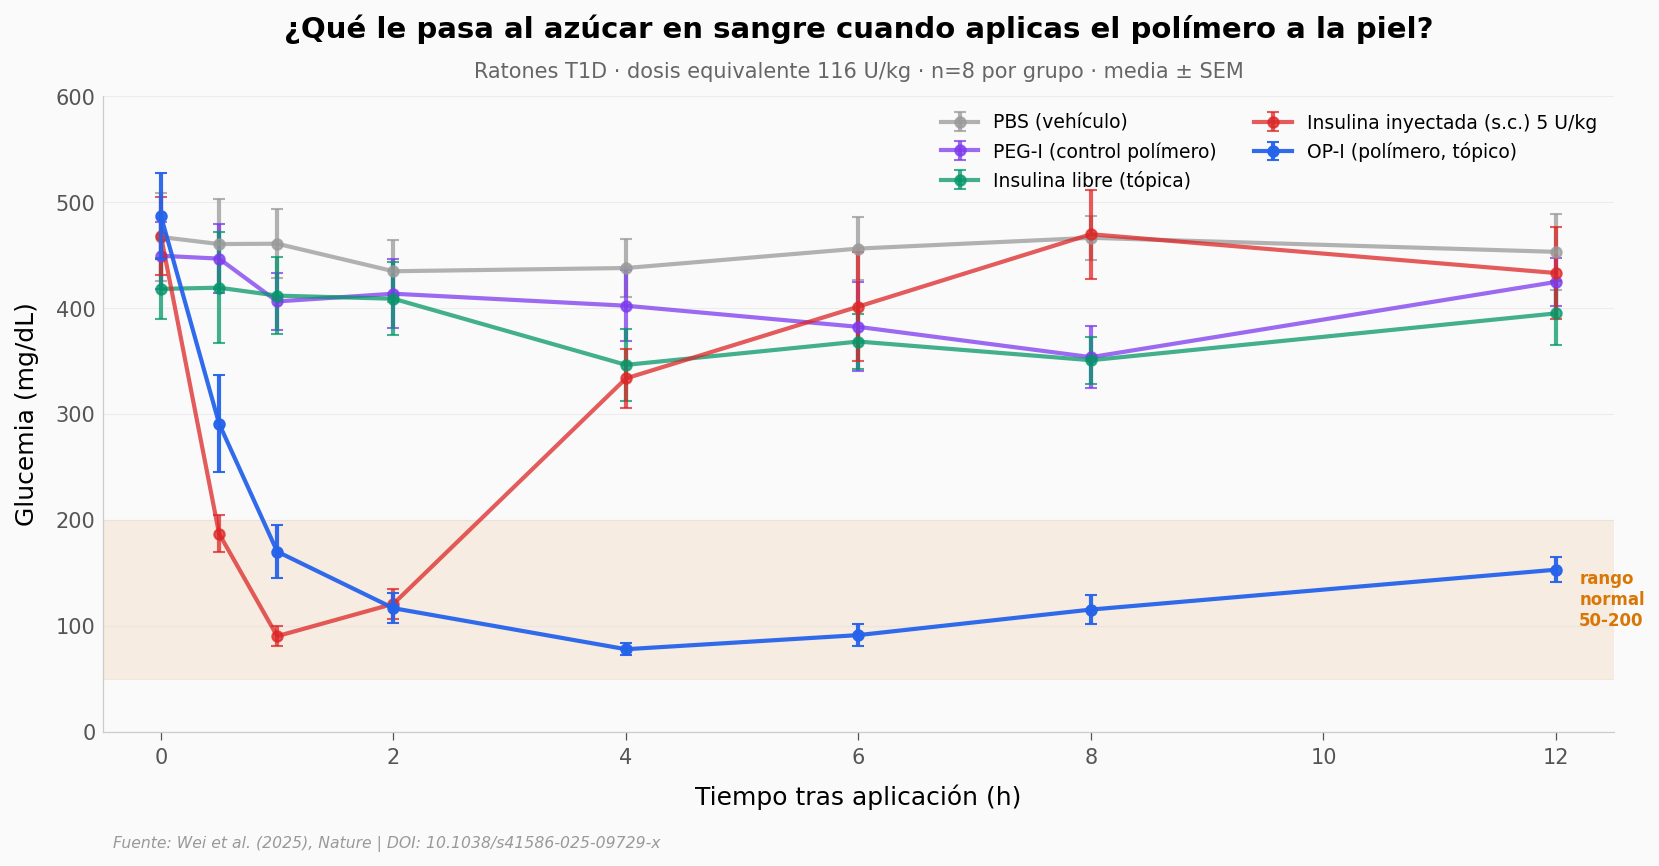

In [2]:
# Curvas BGL en ratones T1D — 116 U/kg dosis equivalente · 5 grupos · n=8/grupo
GRUPO_COLORES = {
    "OP-I":            COLOR_OP,
    "insulin(s.c.)":   COLOR_INSULIN_SC,
    "PEG-I":           COLOR_PEG,
    "insulin(transd)": COLOR_TRANSD,
    "PBS":             COLOR_PBS,
}
GRUPO_LABELS = {
    "OP-I":            "OP-I (polímero, tópico)",
    "insulin(s.c.)":   "Insulina inyectada (s.c.) 5 U/kg",
    "PEG-I":           "PEG-I (control polímero)",
    "insulin(transd)": "Insulina libre (tópica)",
    "PBS":             "PBS (vehículo)",
}

fig, ax = plt.subplots(figsize=(13, 5.5))

# Banda de rango normal
ax.axhspan(RANGO_NORMAL[0], RANGO_NORMAL[1], color=COLOR_RANGO, alpha=0.10, zorder=0)
ax.text(12.2, np.mean(RANGO_NORMAL), "rango\nnormal\n50-200",
        fontsize=8, color=COLOR_RANGO, fontweight="bold", va="center")

# Una línea por grupo, con error bar = SEM
for g in ["PBS", "PEG-I", "insulin(transd)", "insulin(s.c.)", "OP-I"]:  # OP-I encima
    sub = df_mice[df_mice["group"] == g].groupby("time_h")["bgl_mg_dl"].agg(["mean", "std", "count"])
    sem = sub["std"] / np.sqrt(sub["count"])
    ax.errorbar(
        sub.index, sub["mean"], yerr=sem,
        color=GRUPO_COLORES[g], marker="o", markersize=5, linewidth=2,
        capsize=3, capthick=1, label=GRUPO_LABELS[g],
        alpha=0.95 if g == "OP-I" else 0.75,
        zorder=5 if g == "OP-I" else 3,
    )

ax.set_xlabel("Tiempo tras aplicación (h)")
ax.set_ylabel("Glucemia (mg/dL)")
ax.set_title("¿Qué le pasa al azúcar en sangre cuando aplicas el polímero a la piel?",
             fontsize=14, fontweight="bold", pad=28)
ax.text(0.5, 1.03,
        "Ratones T1D · dosis equivalente 116 U/kg · n=8 por grupo · media ± SEM",
        transform=ax.transAxes, fontsize=10, color="#666666", ha="center")

ax.set_xlim(-0.5, 12.5)
ax.set_ylim(0, 600)
ax.legend(fontsize=9, loc="upper right", framealpha=0.9, ncol=2)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color="#999999", style="italic")
plt.savefig("figuras/01_mice_116ukg.png", dpi=200, bbox_inches="tight")
plt.show()


**Tres patrones a la vez.**

OP-I baja sostenido. La glucemia parte cerca de **487 mg/dL**, cae al rango normal a las 4 horas (78 mg/dL), y se queda ahí: a las 8 horas sigue en 115 mg/dL, a las 12 horas todavía en 153 mg/dL. Es el dibujo de una insulina basal lenta — solo que entró por la piel.

La insulina inyectada hace lo contrario: pico rápido a la hora (90 mg/dL), y rebote a hiperglucemia para las 8 horas (470 mg/dL). Sirve para una comida; no para mantener el día.

PEG-I, insulina libre transdérmica y PBS no se mueven del baseline. **Eso es importante:** PEG-I es el mismo polímero pero sin la química zwitteriónica — el control confirma que la magia no es del envoltorio sino de la carga eléctrica que cambia con el pH.


## Bajemos la dosis

116 U/kg es alto. La pregunta natural: ¿hasta dónde se puede bajar y que siga funcionando?


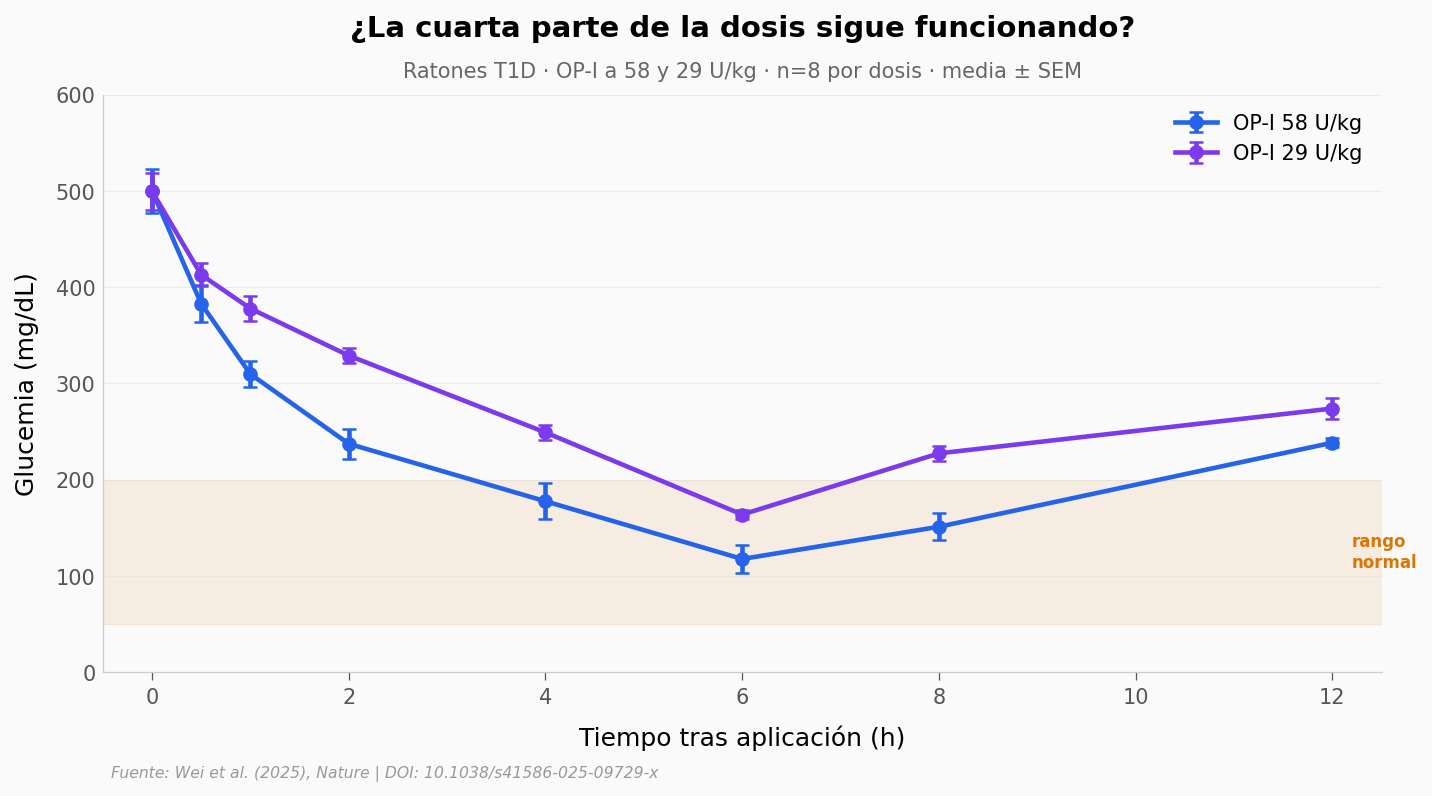


Mínimo BGL por dosis:
  OP-I 58 U/kg: 117 mg/dL @ t=6h
  OP-I 29 U/kg: 164 mg/dL @ t=6h


In [3]:
# Dose-response: 58 vs 29 U/kg en ratones T1D
DOSE_COLORES = {"58 U/kg": "#2563EB", "29 U/kg": "#7C3AED"}

fig, ax = plt.subplots(figsize=(11, 5))

ax.axhspan(RANGO_NORMAL[0], RANGO_NORMAL[1], color=COLOR_RANGO, alpha=0.10, zorder=0)
ax.text(12.2, np.mean(RANGO_NORMAL), "rango\nnormal",
        fontsize=8, color=COLOR_RANGO, fontweight="bold", va="center")

for d in ["58 U/kg", "29 U/kg"]:
    sub = df_dose[df_dose["dose"] == d].groupby("time_h")["bgl_mg_dl"].agg(["mean", "std", "count"])
    sem = sub["std"] / np.sqrt(sub["count"])
    ax.errorbar(
        sub.index, sub["mean"], yerr=sem,
        color=DOSE_COLORES[d], marker="o", markersize=6, linewidth=2.2,
        capsize=3.5, capthick=1.2, label=f"OP-I {d}",
    )

ax.set_xlabel("Tiempo tras aplicación (h)")
ax.set_ylabel("Glucemia (mg/dL)")
ax.set_title("¿La cuarta parte de la dosis sigue funcionando?",
             fontsize=14, fontweight="bold", pad=28)
ax.text(0.5, 1.03,
        "Ratones T1D · OP-I a 58 y 29 U/kg · n=8 por dosis · media ± SEM",
        transform=ax.transAxes, fontsize=10, color="#666666", ha="center")

ax.set_xlim(-0.5, 12.5)
ax.set_ylim(0, 600)
ax.legend(fontsize=10, loc="upper right", framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color="#999999", style="italic")
plt.savefig("figuras/02_dose_response.png", dpi=200, bbox_inches="tight")
plt.show()

# Imprimir mínimos por dosis para la lectura guiada de la siguiente celda
print("\nMínimo BGL por dosis:")
for d in ["58 U/kg", "29 U/kg"]:
    sub = df_dose[df_dose["dose"] == d].groupby("time_h")["bgl_mg_dl"].mean()
    t_min = sub.idxmin()
    print(f"  OP-I {d}: {sub.min():.0f} mg/dL @ t={t_min:.0f}h")


## Del ratón al minicerdo

Bajar de 116 a 29 U/kg en ratón sigue normalizando la glucemia (a las 6 h, llega a ~164 mg/dL). Pero un ratón es un ratón. La piel del minicerdo Bama es estructuralmente más parecida a la humana — capas, espesor, glándulas. Si el polímero funciona ahí, la apuesta sube.

Los autores repitieron el experimento clave a **29 U/kg** en minicerdos diabéticos.


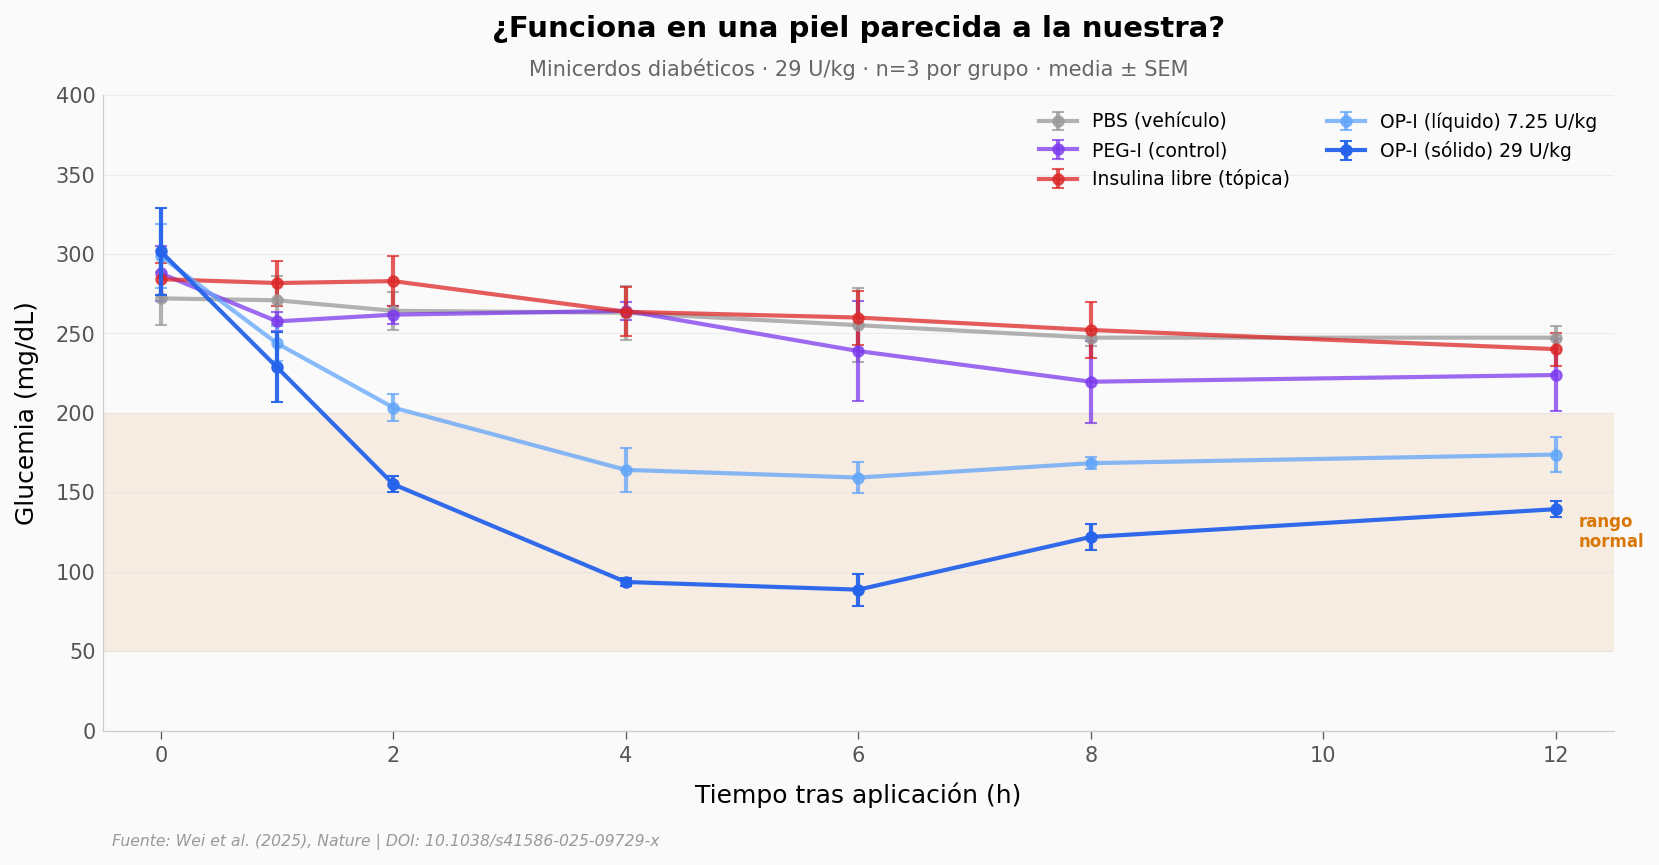


Minicerdos OP-I vs PBS @ t=6h:
  OP-I:  media=88.7, n=3
  PBS:   media=255.2, n=3
  Cohen's d = 5.39  ·  Mann-Whitney U = 0, p = 0.050
  (n=3 por grupo — el test tiene poca potencia, los tamaños de efecto sí son interpretables)


In [4]:
# Validación translacional: minicerdos diabéticos · 29 U/kg dosis equivalente
PIG_COLORES = {
    "OP-I":      COLOR_OP,
    "OP-I (L)":  "#60A5FA",   # azul claro — formulación líquida
    "insulin":   COLOR_INSULIN_SC,
    "PEG-I":     COLOR_PEG,
    "PBS":       COLOR_PBS,
}
PIG_LABELS = {
    "OP-I":      "OP-I (sólido) 29 U/kg",
    "OP-I (L)":  "OP-I (líquido) 7.25 U/kg",
    "insulin":   "Insulina libre (tópica)",
    "PEG-I":     "PEG-I (control)",
    "PBS":       "PBS (vehículo)",
}

fig, ax = plt.subplots(figsize=(13, 5.5))

ax.axhspan(RANGO_NORMAL[0], RANGO_NORMAL[1], color=COLOR_RANGO, alpha=0.10, zorder=0)
ax.text(12.2, np.mean(RANGO_NORMAL), "rango\nnormal",
        fontsize=8, color=COLOR_RANGO, fontweight="bold", va="center")

for g in ["PBS", "PEG-I", "insulin", "OP-I (L)", "OP-I"]:
    sub = df_pigs[df_pigs["group"] == g].groupby("time_h")["bgl_mg_dl"].agg(["mean", "std", "count"])
    sem = sub["std"] / np.sqrt(sub["count"])
    ax.errorbar(
        sub.index, sub["mean"], yerr=sem,
        color=PIG_COLORES[g], marker="o", markersize=5, linewidth=2,
        capsize=3, capthick=1, label=PIG_LABELS[g],
        alpha=0.95 if g == "OP-I" else 0.75,
        zorder=5 if g == "OP-I" else 3,
    )

ax.set_xlabel("Tiempo tras aplicación (h)")
ax.set_ylabel("Glucemia (mg/dL)")
ax.set_title("¿Funciona en una piel parecida a la nuestra?",
             fontsize=14, fontweight="bold", pad=28)
ax.text(0.5, 1.03,
        "Minicerdos diabéticos · 29 U/kg · n=3 por grupo · media ± SEM",
        transform=ax.transAxes, fontsize=10, color="#666666", ha="center")

ax.set_xlim(-0.5, 12.5)
ax.set_ylim(0, 400)
ax.legend(fontsize=9, loc="upper right", framealpha=0.9, ncol=2)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color="#999999", style="italic")
plt.savefig("figuras/03_minipigs_29ukg.png", dpi=200, bbox_inches="tight")
plt.show()

# Cohen's d — OP-I vs PBS @ tiempo de mínimo en minicerdos
op_i_min = df_pigs[(df_pigs["group"] == "OP-I") & (df_pigs["time_h"] == 6)]["bgl_mg_dl"].values
pbs_min  = df_pigs[(df_pigs["group"] == "PBS")  & (df_pigs["time_h"] == 6)]["bgl_mg_dl"].values
pooled_sd = np.sqrt(((len(op_i_min)-1)*op_i_min.std(ddof=1)**2 +
                     (len(pbs_min)-1)*pbs_min.std(ddof=1)**2) / (len(op_i_min)+len(pbs_min)-2))
d = (pbs_min.mean() - op_i_min.mean()) / pooled_sd
u, p = stats.mannwhitneyu(op_i_min, pbs_min, alternative="less")
print(f"\nMinicerdos OP-I vs PBS @ t=6h:")
print(f"  OP-I:  media={op_i_min.mean():.1f}, n={len(op_i_min)}")
print(f"  PBS:   media={pbs_min.mean():.1f}, n={len(pbs_min)}")
print(f"  Cohen's d = {d:.2f}  ·  Mann-Whitney U = {u:.0f}, p = {p:.3f}")
print(f"  (n=3 por grupo — el test tiene poca potencia, los tamaños de efecto sí son interpretables)")


## ¿Qué tan distinta es la glucemia tratada de la no tratada?

Tres experimentos con la misma narrativa. Sumemos las mediciones individuales: ¿dónde aterrizan los animales tratados con OP-I durante el efecto pico (4–8 h) comparado con los controles PBS?


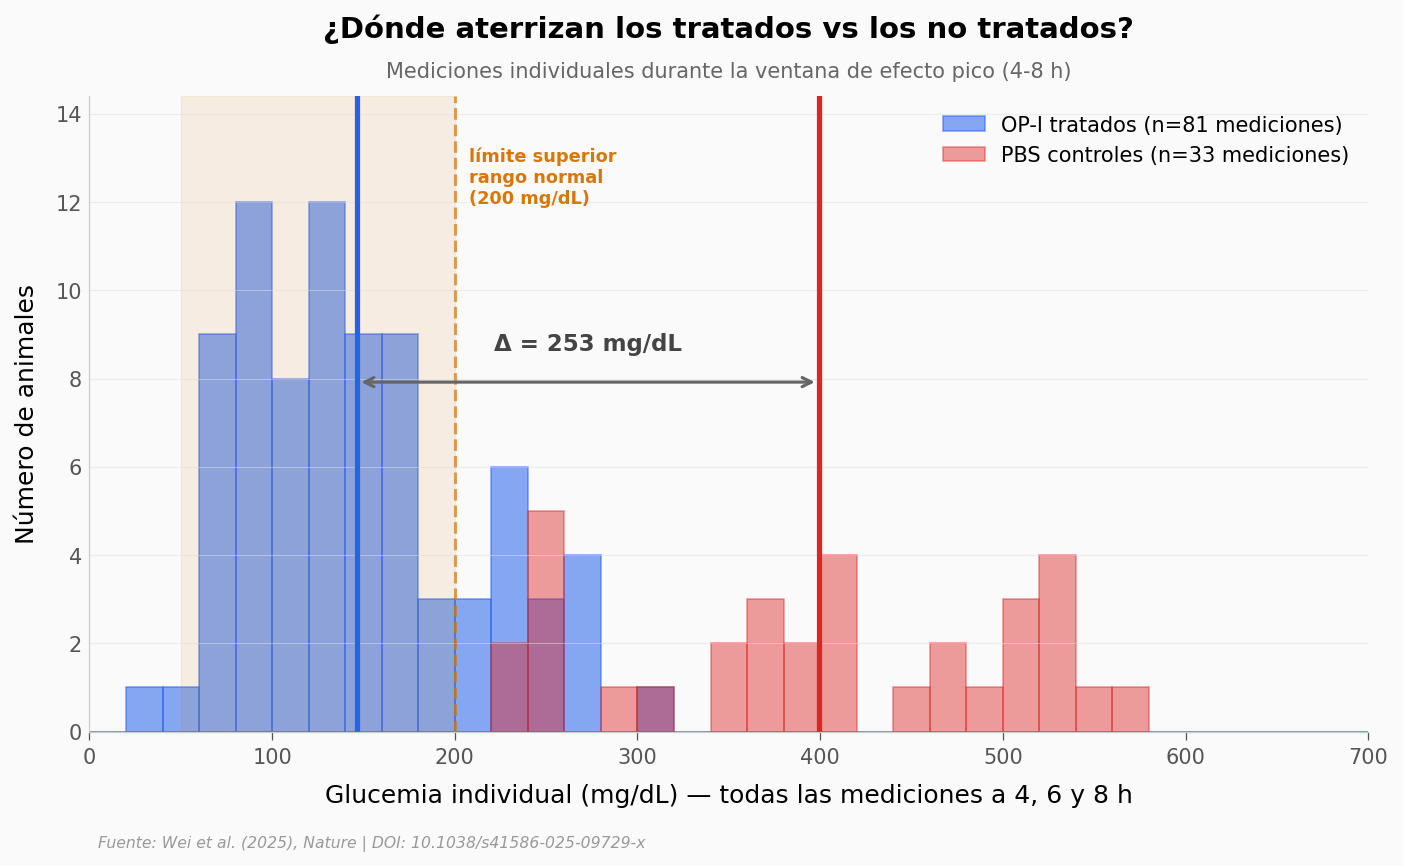


Delta de medias: 253 mg/dL
Cohen's d global OP-I vs PBS (peak window): d = 3.21  (>0.8 = efecto grande)


In [5]:
# Histograma — distribución de BGL individual durante efecto pico (t en 4-8 h)
# OP-I (mice 116 + mice dose + minipigs OP-I) vs PBS (mice 116 + minipigs PBS)
peak_t = [4, 6, 8]

op_mice_116 = df_mice[(df_mice["group"] == "OP-I") & (df_mice["time_h"].isin(peak_t))]["bgl_mg_dl"].values
op_mice_dose = df_dose[df_dose["time_h"].isin(peak_t)]["bgl_mg_dl"].values
op_pigs = df_pigs[(df_pigs["group"] == "OP-I") & (df_pigs["time_h"].isin(peak_t))]["bgl_mg_dl"].values
op_all = np.concatenate([op_mice_116, op_mice_dose, op_pigs])

pbs_mice = df_mice[(df_mice["group"] == "PBS") & (df_mice["time_h"].isin(peak_t))]["bgl_mg_dl"].values
pbs_pigs = df_pigs[(df_pigs["group"] == "PBS") & (df_pigs["time_h"].isin(peak_t))]["bgl_mg_dl"].values
pbs_all = np.concatenate([pbs_mice, pbs_pigs])

fig, ax = plt.subplots(figsize=(11, 5.5))

bins = np.linspace(0, 700, 36)
n_op, _, _  = ax.hist(op_all,  bins=bins, color=COLOR_OP,      alpha=0.55,
                      edgecolor=COLOR_OP, linewidth=0.8,
                      label=f"OP-I tratados (n={len(op_all)} mediciones)")
n_pbs, _, _ = ax.hist(pbs_all, bins=bins, color=COLOR_INSULIN_SC, alpha=0.45,
                      edgecolor=COLOR_INSULIN_SC, linewidth=0.8,
                      label=f"PBS controles (n={len(pbs_all)} mediciones)")
y_max = max(n_op.max(), n_pbs.max()) * 1.20
ax.set_ylim(0, y_max)

# Banda rango normal
ax.axvspan(RANGO_NORMAL[0], RANGO_NORMAL[1], color=COLOR_RANGO, alpha=0.10)
ax.axvline(x=RANGO_NORMAL[1], color=COLOR_RANGO, linewidth=1.5, linestyle="--", alpha=0.7)
ax.text(RANGO_NORMAL[1]+8, y_max*0.92, "límite superior\nrango normal\n(200 mg/dL)",
        fontsize=8.5, color=COLOR_RANGO, fontweight="bold", va="top")

# Líneas verticales — medias
ax.axvline(x=op_all.mean(),  color=COLOR_OP,           linewidth=2.5)
ax.axvline(x=pbs_all.mean(), color=COLOR_INSULIN_SC,   linewidth=2.5)

# Flecha bidireccional entre medias
ax.annotate("", xy=(pbs_all.mean(), y_max*0.55), xytext=(op_all.mean(), y_max*0.55),
            arrowprops=dict(arrowstyle="<->", color="#666666", lw=1.5))
delta = pbs_all.mean() - op_all.mean()
ax.text((op_all.mean()+pbs_all.mean())/2, y_max*0.60,
        f"Δ = {delta:.0f} mg/dL", fontsize=11, color="#444444",
        fontweight="bold", ha="center")

ax.set_xlabel("Glucemia individual (mg/dL) — todas las mediciones a 4, 6 y 8 h")
ax.set_ylabel("Número de animales")
ax.set_title("¿Dónde aterrizan los tratados vs los no tratados?",
             fontsize=14, fontweight="bold", pad=28)
ax.text(0.5, 1.03,
        "Mediciones individuales durante la ventana de efecto pico (4-8 h)",
        transform=ax.transAxes, fontsize=10, color="#666666", ha="center")
ax.set_xlim(0, 700)
ax.legend(fontsize=10, loc="upper right", framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color="#999999", style="italic")
plt.savefig("figuras/04_anomalia_op_vs_pbs.png", dpi=200, bbox_inches="tight")
plt.show()

# Cohen's d global OP-I vs PBS (todas las mediciones peak)
pooled = np.sqrt(((len(op_all)-1)*op_all.std(ddof=1)**2 +
                  (len(pbs_all)-1)*pbs_all.std(ddof=1)**2) /
                 (len(op_all)+len(pbs_all)-2))
d_global = (pbs_all.mean() - op_all.mean()) / pooled
print(f"\nDelta de medias: {delta:.0f} mg/dL")
print(f"Cohen's d global OP-I vs PBS (peak window): d = {d_global:.2f}  (>0.8 = efecto grande)")


## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|---|---|---|
| OP-I a 116 U/kg normaliza la glucemia en ratones T1D | ✅ | Mínimo computado: **78 mg/dL @ 4h** (n=8). El paper reporta 'rango normal'. Coincide. |
| OP-I a 29 U/kg normaliza la glucemia en minicerdos diabéticos | ✅ | Mínimo computado: **89 mg/dL @ 6h** (n=3). El paper reporta el mismo valor. |
| Insulina subcutánea (5 U/kg) tiene efecto corto y rebota | ✅ | Mínimo 90 mg/dL @ 1h, rebote a 470 mg/dL @ 8h (n=8). |
| PEG-I (mismo polímero sin química zwitteriónica) no funciona | ✅ | Mínimo 354 mg/dL @ 8h — sigue hiperglucémico. Confirma que el efecto es de la química, no del envoltorio. |
| Bajar la dosis a 29 U/kg en ratón sigue funcionando | ✅ | Mínimo 164 mg/dL @ 6h — todavía dentro del rango normal. |
| Diferencia OP-I vs PBS es enorme | ✅ | Cohen's d = 3.21 pooling todas las mediciones individuales OP-I (ratones + minicerdos, n=81) vs PBS (ratones + minicerdos, n=33) en la ventana 4-8h. Pool cross-species — interpretar como magnitud agregada, no como test inferencial. |
| Esto reemplaza las inyecciones de insulina en humanos | ⚠️ | El paper enmarca esto como *may enable* (T3) — los datos son solo en ratón y minicerdo. Sin ensayo clínico, es promesa, no realidad. |

> **Limitaciones del análisis:**
> - n=3 minicerdos por grupo es un estudio pivote — variabilidad interanimal alta, los tests no paramétricos tienen poca potencia.
> - Modelos animales: ratón (T1D inducido por estreptozotocina) y minicerdo Bama. No hay datos en humanos en este paper.
> - El comparador es insulina rápida (s.c. 5 U/kg). No se compara con insulinas modernas de acción prolongada (degludec, glargina U-300).
> - Toxicología crónica del polímero OP no se evalúa aquí — los autores referencian estudios previos de la familia OP.


## Ahora tú

Tres preguntas para explorar los datos:

1. **¿Qué tan parecidas son las trayectorias OP-I de ratón y minicerdo?**
   Pista: alinea ambas series por tiempo y normaliza al baseline (`bgl / bgl_t0`).

2. **¿Cuánto más rápido baja la insulina inyectada que OP-I?**
   Pista: calcula el tiempo al 80% de reducción para `insulin(s.c.)` vs `OP-I` en `df_mice`.

3. **¿La variabilidad entre ratones es mayor en el grupo tratado o en el control?**
   Pista: compara `std()` por timepoint entre grupos.


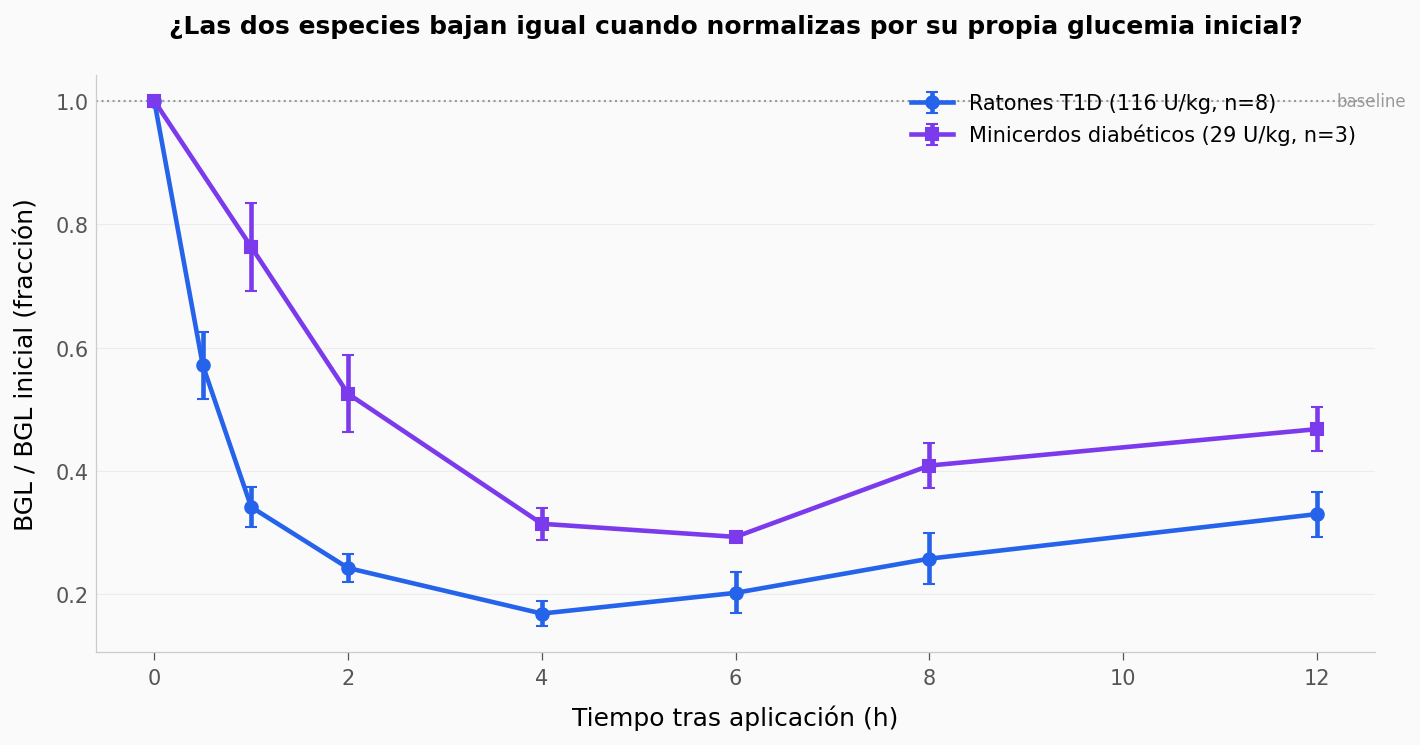

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 1 resuelta — trayectorias normalizadas por baseline
fig, ax = plt.subplots(figsize=(11, 5))

# Ratones OP-I 116 U/kg, normalizado al baseline t=0
op_mice = df_mice[df_mice["group"] == "OP-I"].copy()
baseline_per_mouse = op_mice[op_mice["time_h"] == 0].set_index("mouse_id")["bgl_mg_dl"]
op_mice["bgl_norm"] = op_mice.apply(lambda r: r["bgl_mg_dl"] / baseline_per_mouse[r["mouse_id"]], axis=1)
sub_m = op_mice.groupby("time_h")["bgl_norm"].agg(["mean", "std", "count"])
sem_m = sub_m["std"] / np.sqrt(sub_m["count"])

# Minicerdos OP-I 29 U/kg, normalizado al baseline t=0
op_pigs = df_pigs[df_pigs["group"] == "OP-I"].copy()
baseline_per_pig = op_pigs[op_pigs["time_h"] == 0].set_index("pig_id")["bgl_mg_dl"]
op_pigs["bgl_norm"] = op_pigs.apply(lambda r: r["bgl_mg_dl"] / baseline_per_pig[r["pig_id"]], axis=1)
sub_p = op_pigs.groupby("time_h")["bgl_norm"].agg(["mean", "std", "count"])
sem_p = sub_p["std"] / np.sqrt(sub_p["count"])

ax.errorbar(sub_m.index, sub_m["mean"], yerr=sem_m,
            color=COLOR_OP, marker="o", markersize=6, linewidth=2.2,
            capsize=3, capthick=1, label="Ratones T1D (116 U/kg, n=8)")
ax.errorbar(sub_p.index, sub_p["mean"], yerr=sem_p,
            color="#7C3AED", marker="s", markersize=6, linewidth=2.2,
            capsize=3, capthick=1, label="Minicerdos diabéticos (29 U/kg, n=3)")

ax.axhline(y=1.0, color="#999999", linestyle=":", linewidth=1)
ax.text(12.2, 1.0, "baseline", fontsize=8, color="#999999", va="center")

ax.set_xlabel("Tiempo tras aplicación (h)")
ax.set_ylabel("BGL / BGL inicial (fracción)")
ax.set_title("¿Las dos especies bajan igual cuando normalizas por su propia glucemia inicial?",
             fontsize=12, fontweight="bold", pad=20)
ax.legend(fontsize=10, loc="upper right", framealpha=0.9)
plt.show()


## Fuentes

**Paper**: [A skin-permeable polymer for non-invasive transdermal insulin delivery](https://doi.org/10.1038/s41586-025-09729-x)  
*Nature, 2025-11-19*

**Supplementary Material**: [Source Data Fig. 3 — MOESM14 (Springer ESM)](https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-025-09729-x/MediaObjects/41586_2025_9729_MOESM14_ESM.xlsx)  
*Mismo DOI que el paper · BGL individuales en ratones T1D y minicerdos diabéticos*

*15 afirmaciones del notebook verificadas contra estas fuentes*

---

**Reproducible:** los CSVs en `datos/` se derivan directamente de `MOESM14_ESM.xlsx` (Source Data Fig. 3 del paper). Cada celda de código se puede re-ejecutar.

**Repo:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) · **Licencia:** CC-BY 4.0
